# Chapter 7: Vector Data with GeoPandas

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Extend Pandas to spatial objects with GeoPandas
- Perform spatial joins, overlays, and geoprocessing
- Understand the GeoDataFrame as a simulation substrate

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## GeoDataFrame Fundamentals

Chapter 6 loaded Maranhão's 217 municipalities and called `.plot()` on them without asking what, exactly, sits inside a `GeoDataFrame`. The honest answer: everything a Chapter 3 `DataFrame` has, plus one special column.

In [2]:
url = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "malhas_territoriais/malhas_municipais/municipio_2025/"
    "UFs/MA/MA_Municipios_2025.zip"
)
maranhao = gpd.read_file(url)
maranhao.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CD_MUN      217 non-null    str     
 1   NM_MUN      217 non-null    str     
 2   CD_RGI      217 non-null    str     
 3   NM_RGI      217 non-null    str     
 4   CD_RGINT    217 non-null    str     
 5   NM_RGINT    217 non-null    str     
 6   CD_UF       217 non-null    str     
 7   NM_UF       217 non-null    str     
 8   SIGLA_UF    217 non-null    str     
 9   CD_REGIAO   217 non-null    str     
 10  NM_REGIAO   217 non-null    str     
 11  SIGLA_RG    217 non-null    str     
 12  CD_CONCURB  11 non-null     str     
 13  NM_CONCURB  11 non-null     str     
 14  AREA_KM2    217 non-null    float64 
 15  geometry    217 non-null    geometry
dtypes: float64(1), geometry(1), str(14)
memory usage: 44.5 KB


Every ordinary column — `NM_MUN`, `SIGLA_UF`, `AREA_KM2` — behaves exactly as it did with `world_data.csv` back in Chapter 3: `.query()`, boolean filtering, `.sort_values()`, all still apply. The one new column, `geometry`, holds a **Shapely** object per row — for a municipality that's almost always a `Polygon` or, when the boundary includes offshore islands (several Maranhão coastal municipalities do), a `MultiPolygon`:

<class 'shapely.geometry.multipolygon.MultiPolygon'>


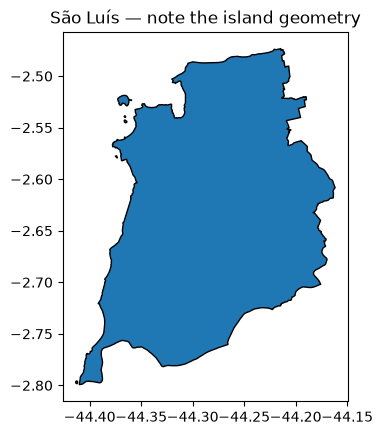

In [3]:
capital = maranhao.query("NM_MUN == 'São Luís'")
print(type(capital.iloc[0].geometry))
capital.plot(edgecolor="black")
plt.title("São Luís — note the island geometry")
plt.show()

Two methods read directly off that geometry column and are worth knowing immediately: `.area` and `.length` (perimeter). Both trust whatever units the *current* CRS uses — and Chapter 6 loaded this data in SIRGAS 2000, a **geographic** CRS measured in degrees, so `.area` right now would return a number in square degrees, which is not a quantity anyone can reason about. Reproject to a UTM zone first, exactly as Chapter 6's CRS section promised:

In [4]:
maranhao_utm = maranhao.to_crs(epsg=31983)  # SIRGAS 2000 / UTM zone 23S
maranhao_utm["area_km2"] = maranhao_utm.geometry.area / 1e6  # m² → km²

maranhao_utm[["NM_MUN", "area_km2"]].sort_values("area_km2", ascending=False).head()

,NM_MUN,area_km2
180,Balsas,12599.277275
213,Alto Parnaíba,11123.507287
77,Grajaú,8857.537944
36,Mirador,8516.515854
133,Centro Novo do Maranhão,8400.480315


If IBGE's own `AREA_KM2` column is still in `maranhao_utm`, compare it against this freshly-computed `area_km2` — they should agree closely. When they don't, the gap is almost always a CRS mismatch, which makes this comparison a useful sanity check to run on *any* new vector dataset, not just this one.

## Spatial Joins

A **spatial join** answers a question an ordinary `pd.merge()` cannot: not "do these two rows share a matching ID," but "does this geometry sit inside, overlap, or touch that one." `geopandas.sjoin()` takes two `GeoDataFrame`s and a **predicate** — `within`, `intersects`, `contains`, and a handful of others — and matches rows exactly where that spatial relationship holds.

The cleanest example is a **point-in-polygon** join: given a handful of coordinates, which municipality polygon contains each one? Build a small `GeoDataFrame` of Maranhão places the same way Chapter 2 built its `cities` dictionary, then join it against `maranhao`:

In [5]:
places = gpd.GeoDataFrame(
    {"name": ["São Luís", "Imperatriz", "Balsas"]},
    geometry=gpd.points_from_xy(
        [-44.3028, -47.4818, -46.0354],   # longitude
        [-2.5297, -5.5264, -7.5325],      # latitude
    ),
    crs="EPSG:4674",  # SIRGAS 2000, matching `maranhao`
)

joined = gpd.sjoin(places, maranhao, predicate="within")
joined[["name", "NM_MUN"]]

,name,NM_MUN
0,São Luís,São Luís
1,Imperatriz,Imperatriz
2,Balsas,Balsas


`sjoin` matched each point against the one municipality polygon that contains it, and copied that polygon's attributes — `NM_MUN` among them — onto the matching point's row. This is precisely the technique Chapter 16 leans on again when it turns proximity into a raw distance number instead of a yes/no match; the predicate changes, but the underlying idea — match by geometry, not by a shared key — does not.

## Overlays and Clipping

A spatial join matches whole geometries against each other. An **overlay** goes a step further and computes an entirely new geometry from the intersection, union, or difference of two layers — the vector equivalent of a Venn diagram, with real polygons on both sides.

`GeoDataFrame.buffer(distance)` creates a new geometry — a "radius" — around every point in a layer, in whatever linear unit the current CRS uses. Combined with `gpd.overlay()`, this answers a genuinely useful question: which parts of which municipalities fall within 50 km of the state capital?

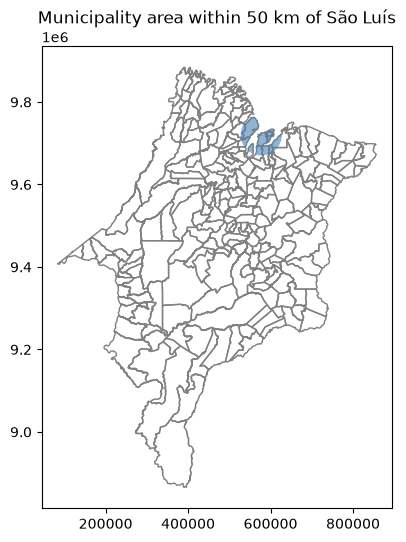

In [6]:
capital_utm = gpd.GeoDataFrame(
    {"name": ["São Luís"]},
    geometry=gpd.points_from_xy([-44.3028], [-2.5297]),
    crs="EPSG:4674",
).to_crs(epsg=31983)

catchment = gpd.GeoDataFrame(
    geometry=capital_utm.buffer(50_000),  # 50 km, in meters (UTM)
    crs=maranhao_utm.crs,
)

nearby = gpd.overlay(maranhao_utm, catchment, how="intersection")
ax = maranhao_utm.plot(edgecolor="gray", facecolor="none", figsize=(6, 6))
nearby.plot(ax=ax, color="steelblue", alpha=0.6)
plt.title("Municipality area within 50 km of São Luís")
plt.show()

Every polygon in `nearby` is clipped exactly at the 50 km circle — a municipality that straddles the boundary is cut in two by the overlay, not included or excluded whole. `gpd.clip()` is a related, simpler operation for the common special case of cutting one layer down to another's boundary without needing the full intersection/union/difference machinery of `overlay()`.

## Geoprocessing Workflows

Real analyses chain several of the operations above into a pipeline, usually ending with the same kind of tabular join Chapter 3 already covered — except now one side of the join is a `GeoDataFrame`, and the payoff is a map instead of a table. A common shape for that pipeline, applicable well beyond Maranhão:

1. Load the geometry (`gpd.read_file`)
2. Load an attribute table separately — a population estimate, a survey result, a sensor reading (`pd.read_csv`)
3. `pd.merge()` the two on a shared key (a municipality code, in IBGE's data)
4. Optionally `dissolve()` to aggregate several geometries into one, carrying attributes along

`dissolve()` is the geometric equivalent of `groupby()` from Chapter 3 — except instead of summing a column per group, it **unions the geometries** in each group into one shape. Dissolving every municipality with no grouping column at all collapses the whole layer into Maranhão's outer state boundary, which doubles as a quick correctness check: the summed area of every municipality should match the dissolved state's area almost exactly, since municipalities don't overlap.

Dissolved state area:      329,575 km²
Sum of municipality areas: 329,575 km²


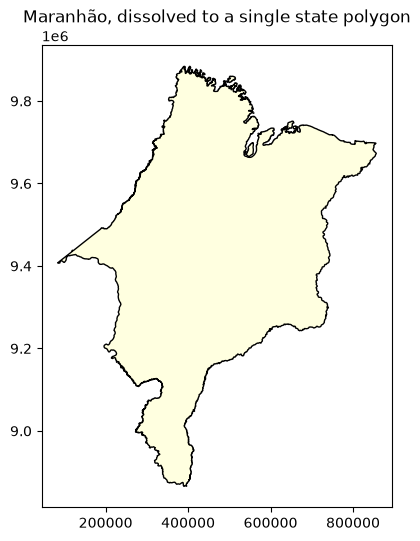

In [7]:
state_boundary = maranhao_utm.dissolve()
state_area = state_boundary.geometry.area.iloc[0] / 1e6
sum_of_parts = maranhao_utm["area_km2"].sum()

print(f"Dissolved state area:      {state_area:,.0f} km²")
print(f"Sum of municipality areas: {sum_of_parts:,.0f} km²")

state_boundary.plot(edgecolor="black", facecolor="lightyellow", figsize=(6, 6))
plt.title("Maranhão, dissolved to a single state polygon")
plt.show()

The two area figures won't match to the last decimal — real boundary data always carries tiny topological slivers and rounding — but a large discrepancy would flag a genuine problem: overlapping municipalities, or a CRS mismatch, exactly the kind of check *GeoDataFrame Fundamentals* introduced above.

## GeoDataFrame as a Simulation Grid

Every technique in this chapter has treated the `GeoDataFrame` as a static map to query. Part IV treats it as something more: the substrate a spatial model actually runs on.

DisSModel's `vector_grid()` function, which Chapter 22 introduces properly, builds a regular grid of square or hexagonal polygons — a `GeoDataFrame` exactly like `maranhao`, just with artificial cells instead of real municipal boundaries. A `SpatialModel` subclass then treats each **row** as a cell (or an agent): its `geometry` column is where that cell sits in space, its other columns are the model's state — `state=0` for "dead" in Chapter 2's toy classifier, `elevation` for a flood model, `fuel_load` for a fire spread model. Advancing the model one time step means updating those attribute columns for every row, using `sjoin`-style neighbor lookups exactly like the point-in-polygon join above to decide which cells influence which.

Nothing about `maranhao` itself needs to be a simulation grid for this to be true — real administrative boundaries are a perfectly valid substrate too, and several models in Parts IV and V (Chapter 26's land-use change models among them) run directly on municipality- or census-tract-level polygons rather than an artificial grid. The unifying idea, carried forward from here to Chapter 21: **a `GeoDataFrame` is state plus geometry, one row at a time** — whether that state is a population estimate you're mapping today, or a variable a model is evolving step by step.

## Exercises

1. **MultiPolygon hunt.** Using `maranhao`, find every municipality whose geometry is a `MultiPolygon` rather than a simple `Polygon` (hint: `.geom_type`). Given Maranhão's coastline, what do you expect these to mostly be?
2. **A second catchment.** Repeat the *Overlays and Clipping* buffer analysis for Imperatriz instead of São Luís, using a 30 km radius. How many municipalities does the buffer touch, compared to the capital's 50 km version?
3. **Dissolve by a real column.** IBGE's municipal shapefile carries a regional grouping column beyond `NM_MUN` (inspect `maranhao.columns` to find it). Dissolve `maranhao_utm` by that column instead of dissolving to a single state, and plot the result — you should see a handful of regions, not 217 municipalities and not one state.
4. **Predicate practice.** Redo the *Spatial Joins* example with `predicate="intersects"` instead of `"within"`. For point-in-polygon data like this, does the result change? Under what circumstances (hint: a point sitting exactly on a shared boundary) might it?

In [8]:
# Your code here

## Summary

### Key concepts introduced

- The `GeoDataFrame`: every Chapter 3 `DataFrame` operation, plus a `geometry` column holding Shapely objects (`Polygon`, `MultiPolygon`, `Point`, ...)
- `.area` and `.length`, and why they're only meaningful after reprojecting to a projected CRS (Chapter 6's rule of thumb, now put to use)
- `gpd.sjoin()` for matching geometries by spatial predicate (`within`, `intersects`, `contains`) rather than a shared key
- `.buffer()` and `gpd.overlay()` for computing genuinely new geometry — intersections, unions, clips — from two layers
- `dissolve()` as the geometric analogue of `groupby()`: aggregating geometries, not just values
- The `GeoDataFrame` as a simulation substrate — the idea Part IV's `SpatialModel` is built on, where each row is a cell or agent carrying both geometry and evolving state

Chapter 8 leaves vector behind and rebuilds this same foundation — data model, reading files, a substrate for simulation — on raster's continuous grid instead.

## Further Reading

- geopandas documentation, *Merging data* (spatial joins): <https://geopandas.org/en/stable/docs/user_guide/mergingdata.html>
- geopandas documentation, *Set operations with overlay*: <https://geopandas.org/en/stable/docs/user_guide/set_operations.html>
- Shapely documentation, *Geometric objects*: <https://shapely.readthedocs.io/en/stable/geometry.html>